In [ ]:
!pip install pytorch_lightning

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

from BinomDataset_ffhq_inpaint_noaug import BinomDataset
from GAP_UNET_ResBlock_ffhq import UN
from tasks import inpainting

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping
import torch.utils.data as dt

if not torch.cuda.is_available():
    raise ValueError("GPU not found, code will run on CPU and can be extremely slow!")
else:
    device = torch.device("cuda:0")

print(f'Device in use: {device}')

Device in use: cuda:0


In [ ]:
os.environ["KAGGLE_KEY"] = '352ba5d0b76d8aabc62dea62e8cd640c'
os.environ["KAGGLE_USERNAME"] = 'weedoo'

!kaggle datasets download -d arnaud58/flickrfaceshq-dataset-ffhq
!unzip "flickrfaceshq-dataset-ffhq.zip" -d "flickrfaceshq-dataset-ffhq"

Streaming output truncated to the last 5000 lines.
  inflating: flickrfaceshq-dataset-ffhq/49001.png  
  inflating: flickrfaceshq-dataset-ffhq/49002.png  
  inflating: flickrfaceshq-dataset-ffhq/49003.png  
  inflating: flickrfaceshq-dataset-ffhq/49004.png  
  inflating: flickrfaceshq-dataset-ffhq/49005.png  
  inflating: flickrfaceshq-dataset-ffhq/49006.png  
  inflating: flickrfaceshq-dataset-ffhq/49007.png  
  inflating: flickrfaceshq-dataset-ffhq/49008.png  
  inflating: flickrfaceshq-dataset-ffhq/49009.png  
  inflating: flickrfaceshq-dataset-ffhq/49010.png  
  inflating: flickrfaceshq-dataset-ffhq/49011.png  
  inflating: flickrfaceshq-dataset-ffhq/49012.png  
  inflating: flickrfaceshq-dataset-ffhq/49013.png  
  inflating: flickrfaceshq-dataset-ffhq/49014.png  
  inflating: flickrfaceshq-dataset-ffhq/49015.png  
  inflating: flickrfaceshq-dataset-ffhq/49016.png  
  inflating: flickrfaceshq-dataset-ffhq/49017.png  
  inflating: flickrfaceshq-dataset-ffhq/49018.png  
  inflating: 

In [ ]:
def psnrToString(inp):
    if inp < 0:
        return 'm'+str(-inp)
    else:
        return str(inp)

minpsnr = -10
maxpsnr = -2.5

name = psnrToString(minpsnr)+"to"+psnrToString(maxpsnr)+"-512x512-ffhq-inpainting-cascade"

CHECKPOINT_PATH = '/content/drive/MyDrive/GAP_Cascade_CKPT'
# os.makedirs(CHECKPOINT_PATH, exist_ok=True)
CHECKPOINT_PATH , name

('/content/drive/MyDrive/GAP_Cascade_CKPT',
 'm32.5tom25-512x512-ffhq-inpainting-cascade')

In [ ]:
maxepochs = 150

dataset = BinomDataset(root = '/content/flickrfaceshq-dataset-ffhq/', windowSize = 256, minPSNR = minpsnr, maxPSNR = maxpsnr, virtSize = 1, imgsize = 512, masksize = 256)


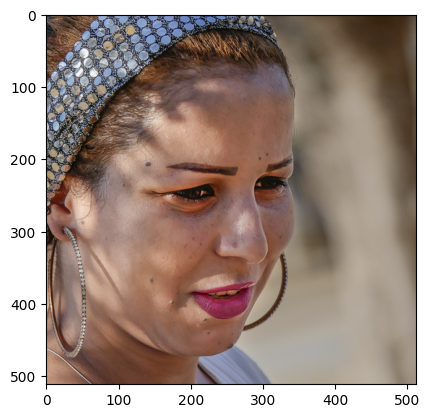

In [ ]:
img = dataset[0]
img = img[:3]/img[:3].max()
plt.imshow(img.permute(1, 2, 0))

In [ ]:
from torch.utils.data import random_split
import random
seed = 42
torch.manual_seed(seed)
random.seed(seed)

# Set the sizes for your train and test sets
total_size = len(dataset)
train_size = int(0.8 * total_size)  # 80% for training
val_size = total_size - train_size  # Remaining 20% for testing

# Split the dataset
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [ ]:
train_loader = dt.DataLoader(dataset, batch_size=14, shuffle=True, drop_last=True, pin_memory=False, num_workers=4) ## Changing the batch size from 32 to 16 to fit inside the gpu
val_loader = dt.DataLoader(val_dataset, batch_size=14, shuffle=False, drop_last=True,  pin_memory=False, num_workers=4)

trainer = pl.Trainer(default_root_dir=os.path.join(CHECKPOINT_PATH, name), gradient_clip_val=0.5,
                     accelerator="gpu",
                     max_time={'hours': 4},
                     max_epochs=maxepochs,
                     callbacks=[ModelCheckpoint(save_weights_only=False, mode="min", monitor="val_loss", every_n_epochs= 1),
                                LearningRateMonitor("epoch"),
                                EarlyStopping('val_loss', patience=2000)])

model = UN(channels = 3, levels=10, depth=6, start_filts=32,
           up_mode = 'upsample', merge_mode = 'concat').to(device)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/content/GAP_UNET_ResBlock_ffhq.py:255: UserWarning: nn.init.xavier_normal is now deprecated in favor of nn.init.xavier_normal_.
  init.xavier_normal(m.weight)
/content/GAP_UNET_ResBlock_ffhq.py:256: UserWarning: nn.init.constant is now deprecated in favor of nn.init.constant_.
  init.constant(m.bias, 0)


In [ ]:
trainer.fit(model, train_loader, val_loader)
trainer.save_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt')

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name       | Type       | Params | Mode 
--------------------------------------------------
0 | conv_final | Conv2d     | 99     | train
1 | down_convs | ModuleList | 31.5 M | train
2 | up_convs   | ModuleList | 13.3 M | train
--------------------------------------------------
44.7 M    Trainable params
0         Non-trainable params
44.7 M    Total params
178.977   Total estimated model params size (MB)
67        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Time limit reached. Elapsed time is 8:00:01. Signaling Trainer to stop.


Validation: |          | 0/? [00:00<?, ?it/s]